In [1]:
#15 june
import pandas as pd
import numpy as np
df = pd.read_csv("airline-passengers.csv")
print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [2]:
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

In [4]:
df['Month']=pd.to_datetime(df['Month'])
df.set_index('Month',inplace = True)

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


In [8]:
print(df.describe())

       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


In [15]:
import matplotlib.pyplot as plt

In [12]:
train = df[:120]
test = df[120:]

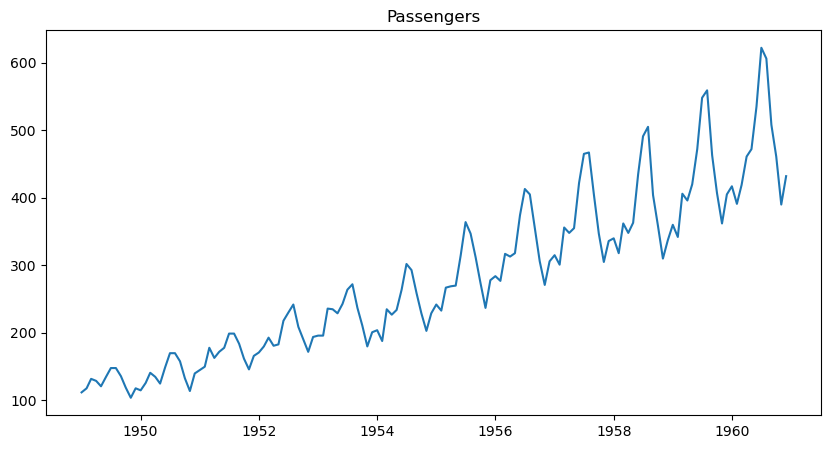

In [17]:
plt.figure(figsize = (10,5))
plt.plot(df['Passengers'])
plt.title("Passengers")
plt.show()

In [18]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(
    train["Passengers"],
    order = (2,1,2)
)
model_fit = model.fit()

C:\Users\Roshan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Roshan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Roshan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [19]:
pred = model_fit.forecast(
    steps = len(test)
)
print(pred)

1959-01-01    336.938023
1959-02-01    348.754477
1959-03-01    368.390290
1959-04-01    390.211579
1959-05-01    408.563774
1959-06-01    419.186026
1959-07-01    420.145604
1959-08-01    412.103638
1959-09-01    397.908151
1959-10-01    381.678765
1959-11-01    367.659095
1959-12-01    359.145163
1960-01-01    357.750409
1960-02-01    363.159533
1960-03-01    373.387061
1960-04-01    385.429012
1960-05-01    396.108227
1960-06-01    402.884150
1960-07-01    404.428090
1960-08-01    400.842144
1960-09-01    393.500306
1960-10-01    384.586674
1960-11-01    376.474351
1960-12-01    371.115043
Freq: MS, Name: predicted_mean, dtype: float64


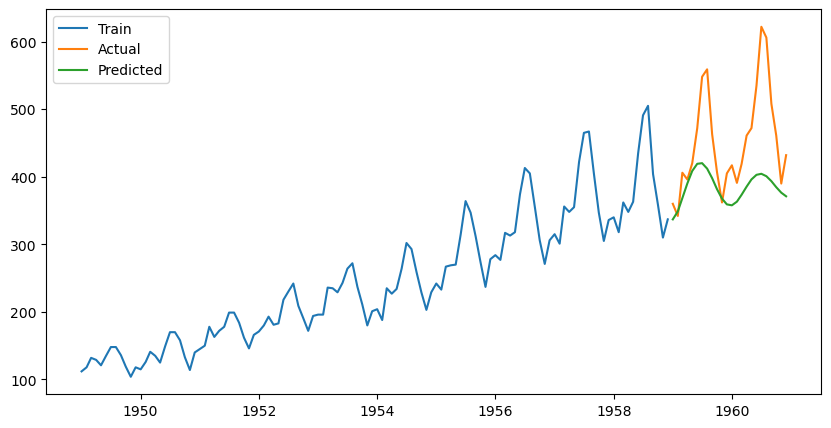

In [21]:
plt.figure(figsize=(10,5))
plt.plot(train.index,
         train['Passengers'],
         label='Train')
plt.plot(test.index,
         test['Passengers'],
         label = 'Actual')
plt.plot(test.index,
         pred,
         label='Predicted')

plt.legend()
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(
test['Passengers'],
pred )
print("MAE: ",mae)

MAE:  69.10323167925911
